# Back Testing

## Fetching data

In [1]:
%run data.ipynb

In [3]:
from datetime import date

In [5]:
test = OHLCData('NEPSE Index', '2021-01-01', str(date.today()), 'NRS', '1D')

In [7]:
test.dump_data()

Data fetched.
Data converted from JSON to CSV.


/tmp/ipykernel_43890/2660219787.py:35: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  timestamps = [datetime.utcfromtimestamp(ts).strftime('%Y-%m-%dT%H:%M:%S') for ts in _timestamps]


## Data structuring

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.utils import dropna

In [12]:
def plot_OHLC(data, ticker, window):
    plt.figure(figsize=(15,5))
    plt.title('{} price data in {} timeframe'.format(ticker, window))
    plt.plot(data['Close'])
    plt.show()

In [14]:
daily_df = pd.read_csv('data.csv')
daily_df = dropna(daily_df)
daily_df['Timestamp'] = pd.to_datetime(daily_df['Timestamp'])
daily_df = daily_df.set_index('Timestamp')

In [16]:
daily_df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2024-11-05,2678.97,2696.85,2670.12,2677.40,4.205505e+09
2024-11-06,2679.47,2684.81,2669.19,2675.51,5.222487e+09
2024-11-10,2681.58,2738.12,2680.70,2738.06,9.771124e+09
2024-11-11,2740.12,2782.43,2734.41,2760.21,1.131521e+10
2024-11-12,2765.69,2788.35,2741.63,2748.96,7.859741e+09


### Converting daily data to weekly

In [19]:
weekly_df = daily_df.resample('W-Sat').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})
weekly_df = dropna(weekly_df)

In [21]:
weekly_df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2024-10-19,2668.08,2780.97,2667.82,2745.36,1.591537e+10
2024-10-26,2733.37,2748.78,2614.65,2627.14,2.995078e+10
2024-11-02,2629.83,2705.24,2610.14,2677.62,2.215950e+10
2024-11-09,2678.97,2696.85,2669.19,2675.51,9.427992e+09
2024-11-16,2681.58,2788.35,2680.70,2748.96,2.894607e+10


### Converting daily data to monthly

In [24]:
monthly_df = daily_df.resample('M').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})
monthly_df = dropna(monthly_df)

/tmp/ipykernel_43890/3912623722.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = daily_df.resample('M').agg({


In [26]:
monthly_df.tail()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2024-07-31,2038.70,2791.02,2030.50,2760.90,2.493892e+11
2024-08-31,2772.23,3048.15,2630.86,2749.57,3.645072e+11
2024-09-30,2749.68,2860.43,2442.61,2508.86,1.588380e+11
2024-10-31,2510.34,2780.97,2510.11,2677.62,1.040098e+11
2024-11-30,2678.97,2788.35,2669.19,2748.96,3.837406e+10


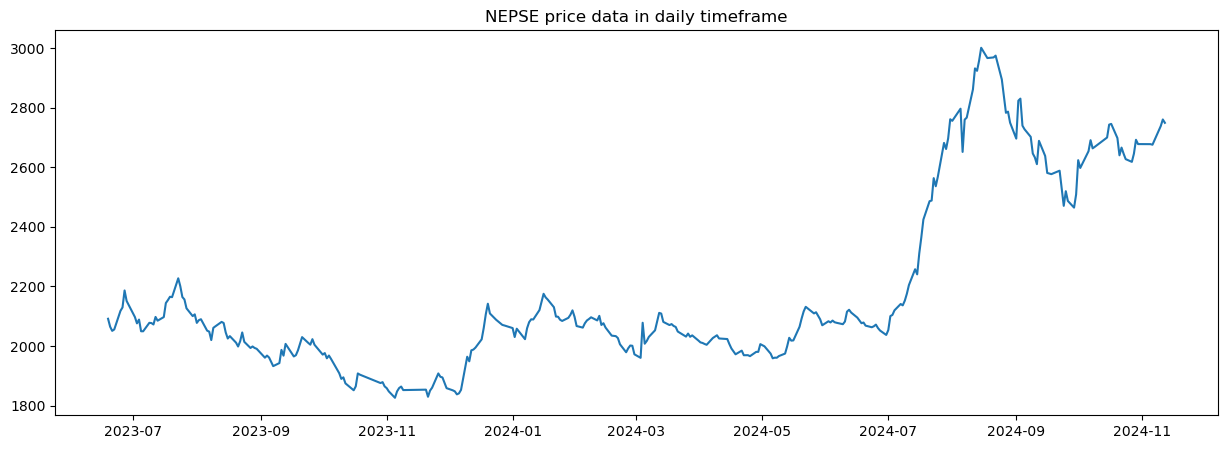

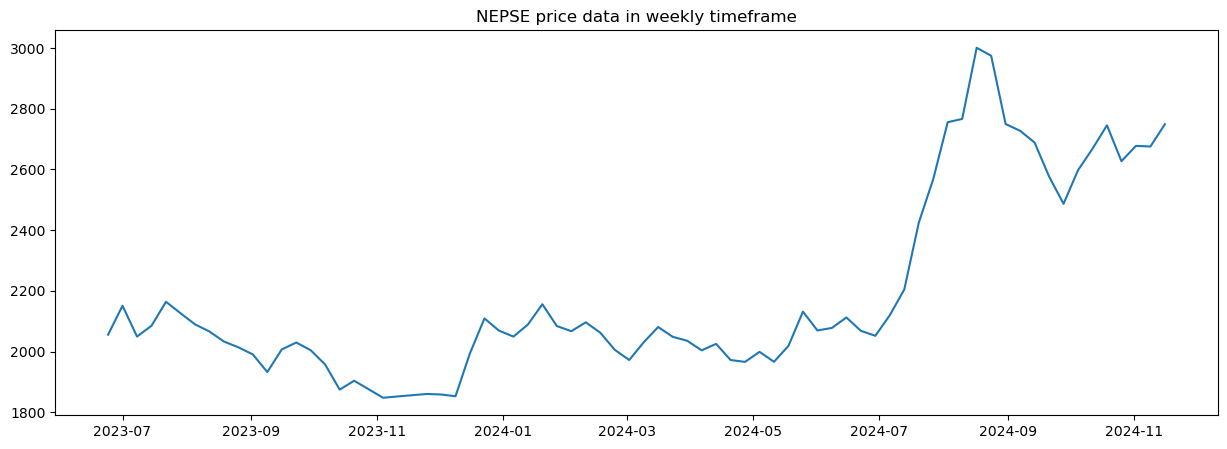

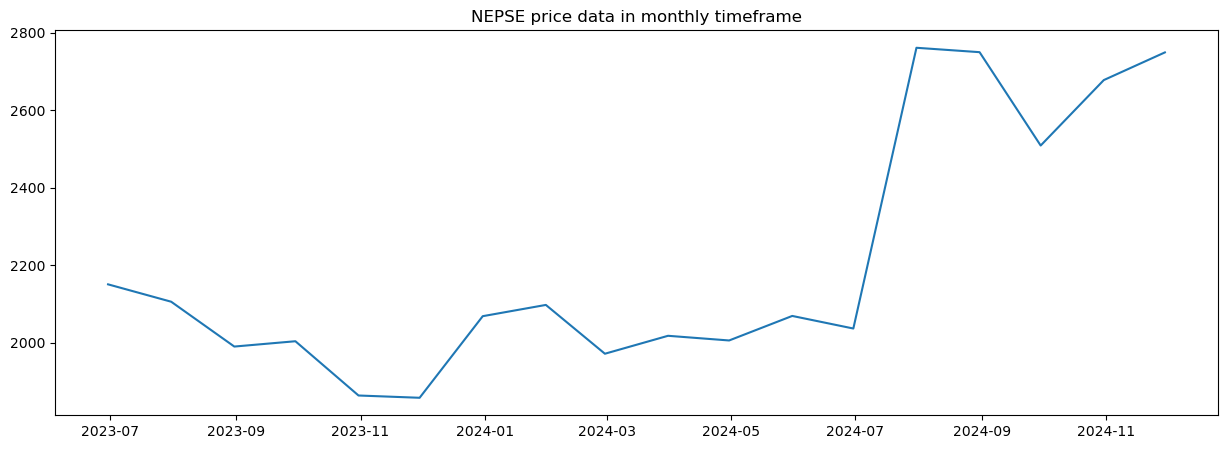

In [28]:
plot_OHLC(daily_df, 'NEPSE', 'daily')
plot_OHLC(weekly_df, 'NEPSE', 'weekly')
plot_OHLC(monthly_df, 'NEPSE', 'monthly')

## Core algorithm

### RSI

In [32]:
from ta.momentum import RSIIndicator

daily_df['RSI'] = RSIIndicator(daily_df['Close'], window=14).rsi()
weekly_df['RSI'] = RSIIndicator(weekly_df['Close'], window=14).rsi()
monthly_df['RSI'] = RSIIndicator(monthly_df['Close'], window=14).rsi()

In [34]:
print(daily_df[['RSI']].tail().to_markdown(), end='\n\n')
print(weekly_df[['RSI']].tail().to_markdown(), end='\n\n')
print(monthly_df[['RSI']].tail().to_markdown(), end='\n\n')

| Timestamp           |     RSI |
|:--------------------|--------:|
| 2024-11-05 00:00:00 | 52.8208 |
| 2024-11-06 00:00:00 | 52.5752 |
| 2024-11-10 00:00:00 | 59.3185 |
| 2024-11-11 00:00:00 | 61.411  |
| 2024-11-12 00:00:00 | 59.7306 |

| Timestamp           |     RSI |
|:--------------------|--------:|
| 2024-10-19 00:00:00 | 63.0578 |
| 2024-10-26 00:00:00 | 56.8001 |
| 2024-11-02 00:00:00 | 58.6855 |
| 2024-11-09 00:00:00 | 58.5704 |
| 2024-11-16 00:00:00 | 61.4071 |

| Timestamp           |     RSI |
|:--------------------|--------:|
| 2024-07-31 00:00:00 | 78.0238 |
| 2024-08-31 00:00:00 | 77.2601 |
| 2024-09-30 00:00:00 | 63.1236 |
| 2024-10-31 00:00:00 | 67.5997 |
| 2024-11-30 00:00:00 | 69.2963 |



<Axes: xlabel='Timestamp'>

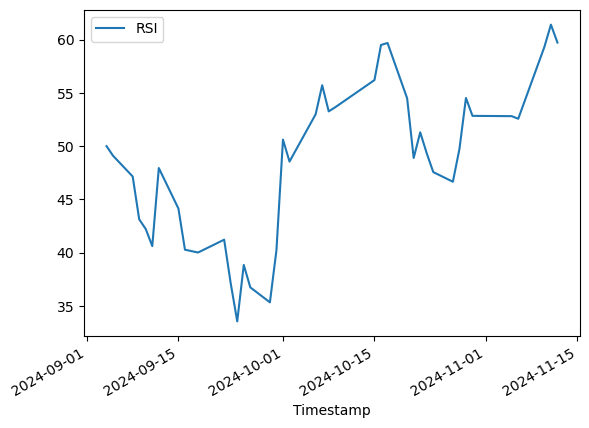

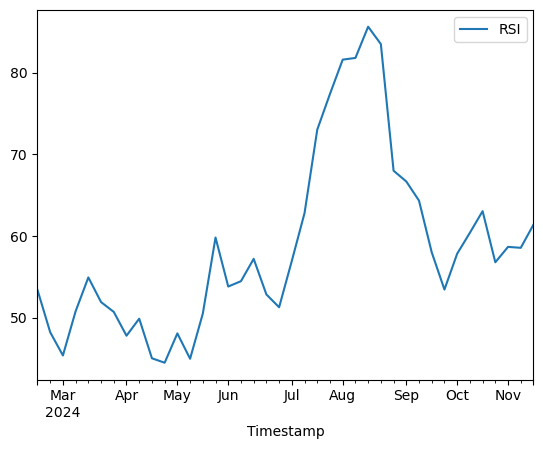

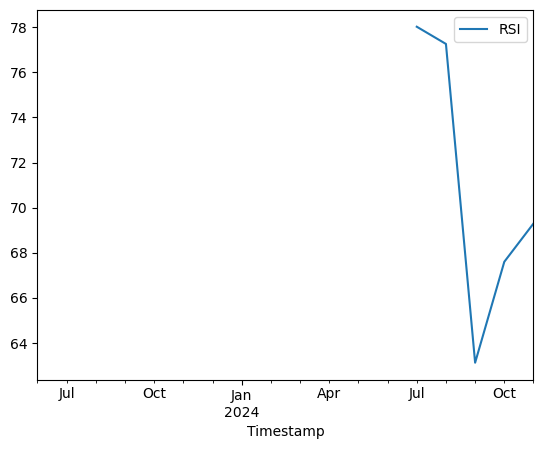

In [36]:
daily_df[['RSI']].tail(40).plot()
weekly_df[['RSI']].tail(40).plot()
monthly_df[['RSI']].tail(40).plot()

In [38]:
from ta.momentum import stochrsi_d, stochrsi_k

# Daily
daily_df['stochrsi_d'] = stochrsi_d(daily_df['Close'], window=14) * 100
daily_df['stochrsi_k'] = stochrsi_k(daily_df['Close'], window=14) * 100

# Weekly
weekly_df['stochrsi_d'] = stochrsi_d(weekly_df['Close'], window=14) * 100
weekly_df['stochrsi_k'] = stochrsi_k(weekly_df['Close'], window=14) * 100

# Monthly
monthly_df['stochrsi_d'] = stochrsi_d(monthly_df['Close'], window=14) * 100
monthly_df['stochrsi_k'] = stochrsi_k(monthly_df['Close'], window=14) * 100

print('Daily stochastic RSI')
print(daily_df[['stochrsi_d', 'stochrsi_k']].tail(10).to_markdown(), end='\n\n')

print('Weekly stochastic RSI')
print(weekly_df[['stochrsi_d', 'stochrsi_k']].tail(10).to_markdown(), end='\n\n')

print('Monthly stochastic RSI')
print(monthly_df[['stochrsi_d', 'stochrsi_k']].tail(10).to_markdown(), end='\n\n')

Daily stochastic RSI
| Timestamp           |   stochrsi_d |   stochrsi_k |
|:--------------------|-------------:|-------------:|
| 2024-10-24 00:00:00 |      53.3446 |     37.4275  |
| 2024-10-27 00:00:00 |      36.3294 |     15.5789  |
| 2024-10-28 00:00:00 |      20.2841 |      7.84593 |
| 2024-10-29 00:00:00 |      17.1293 |     27.963   |
| 2024-10-30 00:00:00 |      26.5318 |     43.7864  |
| 2024-11-05 00:00:00 |      41.1484 |     51.6957  |
| 2024-11-06 00:00:00 |      47.3958 |     46.7052  |
| 2024-11-10 00:00:00 |      53.8878 |     63.2624  |
| 2024-11-11 00:00:00 |      63.6027 |     80.8406  |
| 2024-11-12 00:00:00 |      79.784  |     95.2491  |

Weekly stochastic RSI
| Timestamp           |   stochrsi_d |   stochrsi_k |
|:--------------------|-------------:|-------------:|
| 2024-09-14 00:00:00 |      62.3659 |      43.833  |
| 2024-09-21 00:00:00 |      46.8026 |      34.137  |
| 2024-09-28 00:00:00 |      33.0883 |      21.295  |
| 2024-10-05 00:00:00 |      22.8685 |

<Axes: xlabel='Timestamp'>

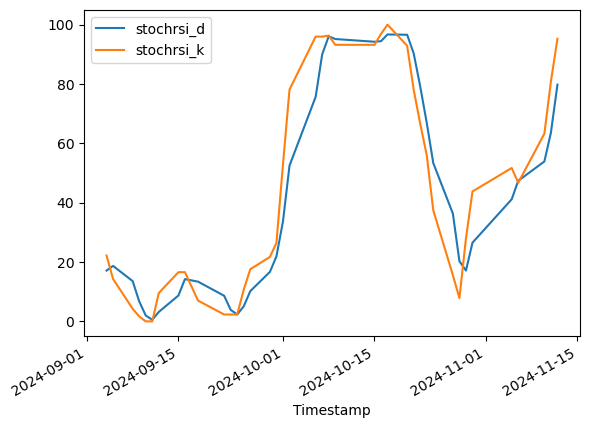

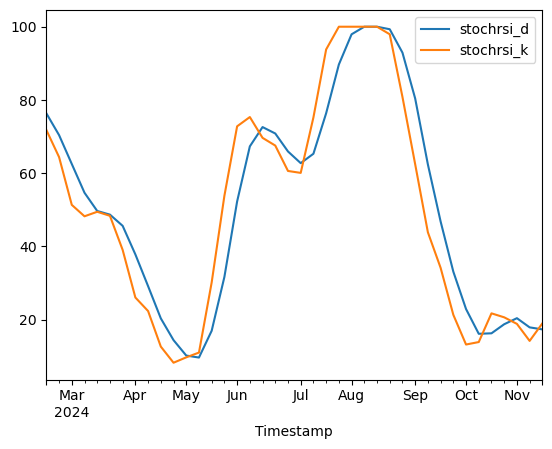

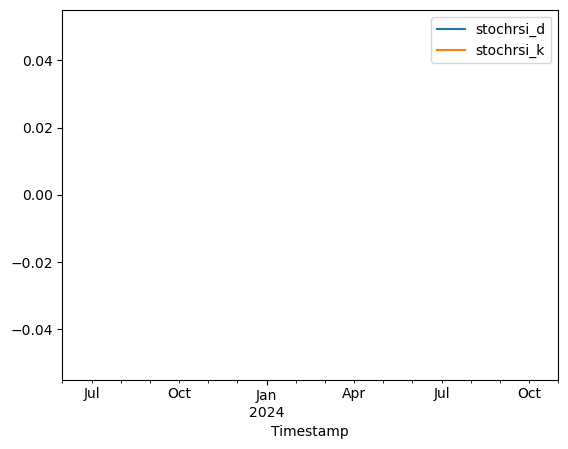

In [40]:
daily_df[['stochrsi_d', 'stochrsi_k']].tail(40).plot()
weekly_df[['stochrsi_d', 'stochrsi_k']].tail(40).plot()
monthly_df[['stochrsi_d', 'stochrsi_k']].tail(40).plot()